In [1]:
import torch
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import random
from matplotlib.patches import Rectangle
import tifffile
import h5py
from torch.utils.data import DataLoader
import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch

import importlib as imp
import sys
sys.path.append(os.path.join(os.path.split(os.getcwd())[0], 'scripts'))

import yolo_tiles
imp.reload(yolo_tiles)
from yolo_tiles import img_to_tiles, apply_model_to_tiles, load_test_image, preprocess, tileDataset, remove_bbox_in_overlap

import yolo_help
imp.reload(yolo_help)
from yolo_help import bbox_to_rectangles, imshow, convert_data, Net, get_best_bounding_box_per_cell

import yolo_post_help
imp.reload(yolo_post_help)
from yolo_post_help import remove_low_conf_bboxes, postprocess, bb_to_rec, NMS

import yolo_help_3D
imp.reload(yolo_help_3D)
from yolo_help_3D import apply_model_to_orthogonal_slices, gen_3D_GT, recon_down, vol_to_mip_rgb, orthogonal_to_3D, vol_to_mip

import yolo_avg_prec
imp.reload(yolo_avg_prec)
from yolo_avg_prec import get_AP, gt_bbox_to_pred_bbox_format, IOU_3D, yolo_output_to_list

import yolo_3D_pipeline_help
imp.reload(yolo_3D_pipeline_help)
from yolo_3D_pipeline_help import apply_2D_yolo_to_slices, stitch_slices_into_cube

from stardist.models import StarDist3D
import nibabel as nib

from csbdeep.utils import normalize

sys.path.append('/ifshome/abenneck/docs_public/libraries/cellpose')
from cellpose import models

2026-08-19 13:18:52.528356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def bb_slice_filter(all_bb, ax_idx, slice_val):
    """
    NOTE: Each elem of all_bb should have at minimum these first 6 values [ax0_min, ax0_max, ax1_min, ax1_max, ax2_min, ax2_max, ...]
    """
    bb_out = []
    for bb in all_bb:
        if ax_idx == 0 and bb[0] <= slice_val and bb[1] >= slice_val:
            bb_out.append(bb)
        elif ax_idx == 1 and bb[2] <= slice_val and bb[3] >= slice_val:
            bb_out.append(bb)
        elif ax_idx == 2 and bb[4] <= slice_val and bb[5] >= slice_val:
            bb_out.append(bb)
        else:
            continue

    if bb_out == []:
        return np.array([])
    return np.stack(bb_out, axis=0)

def gt_mask_to_bb_list(mask_path, verbose=False):
    """
    Converts an integer-valued array into a set of bounding boxes around each unique instance.
    """
    # Load the GT annotation
    mask = nib.load(mask_path)
    
    # 0: Bg, 1: Annotated bg, 2+: Cell ID
    gt_bb = []
    vals_to_skip = [0, 1]
    n_cells = len(np.unique(mask.get_fdata())) - 2 # 0 is bg and 1 is annotated bg
    for val in np.unique(mask.get_fdata()):
        if val in vals_to_skip:
            continue
        mask_cell = np.copy(mask.get_fdata())
        mask_cell[mask_cell != val] = 0.0
        mask_cell[mask_cell == val] = 1.0
        if verbose:
            print(f'Cell {(val-1).astype(int)} / {n_cells} volume of {np.sum(mask_cell).astype(int)} voxels')
        all_x, all_y, all_z = np.where(mask_cell == 1.0)
        gt_bb.append([min(all_x).item(), max(all_x).item(), min(all_y).item(), max(all_y).item(), min(all_z).item(), max(all_z).item(), int(val)])

    return gt_bb

def yolo_output_to_bb_list(out):
    return out.reshape(out.shape[0]*out.shape[1]*out.shape[2],out.shape[3])

def stardist_to_bb_list(raw_output, mode='2D'):
    """
    Converts a standard output from the 2D or 3D StarDist models to a set of bounding boxes
    """

    bb_out = []
    if mode == '2D':
        for i in range(len(raw_output['coord'])):
            coords = raw_output['coord'][i]
            center = raw_output['points'][i]
            prob = float(raw_output['prob'][i])
    
            xmin = float(min(coords[1]))
            xmax = float(max(coords[1]))
            ymin = float(min(coords[0]))
            ymax = float(max(coords[0]))
    
            bb_out.append([xmin, xmax, ymin, ymax, prob])
    elif mode == '3D':
        n_ray = raw_output['dist'].shape[1]
        n_cells = raw_output['dist'].shape[0]
        n_dim = raw_output['points'].shape[1]
        for i in range(n_cells):
            prob = raw_output['prob'][i]
            center = raw_output['points'][i]
            n_vectors = [raw_output['rays_vertices'][j]*raw_output['dist'][i][j] for j in range(n_ray)]
            n_vectors = np.asarray(n_vectors) + center
        
            xmin, ymin, zmin = np.min(n_vectors, axis=0)
            xmax, ymax, zmax = np.max(n_vectors, axis=0)
        
            bb_out.append([xmin, xmax, ymin, ymax, zmin, zmax, prob])
    else:
        print(f'Invalid mode - {mode}; Expected 2D or 3D')
        
    return np.asarray(bb_out)

def cellpose_to_bb_list(mask, verbose=False):
    """
    Converts an integer-valued array into a set of bounding boxes around each unique instance.

    Output bbox format: [xmin xmax ymin ymax zmin zmax cell# conf]
    """
    # 0: Bg, 1+: Cell ID
    bb_out = []
    vals_to_skip = [0]
    n_cells = len(np.unique(mask)) - 1 # 0 is bg
    for val in np.unique(mask):
        if val in vals_to_skip:
            continue
        mask_cell = np.copy(mask)
        mask_cell[mask_cell != val] = 0.0
        mask_cell[mask_cell == val] = 1.0
        if verbose:
            print(f'Cell {(val-1).astype(int)} / {n_cells} volume of {np.sum(mask_cell).astype(int)} voxels')
        all_x, all_y, all_z = np.where(mask_cell == 1.0)
        bb_out.append([min(all_x).item(), max(all_x).item(), min(all_y).item(), max(all_y).item(), min(all_z).item(), max(all_z).item(), int(val), 1.0])
    return np.array(bb_out)

def preprocess_3D(img, upsample = True, gamma = True, norm = True):

    img_out = np.copy(img)
    
    # Apply a gamma correction (gamma = 1/2)
    if gamma:
        img_out = img_out**(1/2)

    # Normalize the image to [0,1]
    if normalize:
        # img_min = np.min(img,axis=(-1,-2,-3),keepdims=True)
        # img_max = np.max(img,axis=(-1,-2,-3),keepdims=True)
        # img_out = (img_out - img_min) / (img_max - img_min)
        img_out = normalize(img_out)
        
    # Upsample the image by a factor of 2 (Inc the size of each voxel from 1 to 2x2x2)
    if upsample:
        out_shape = [i*2 for i in img.shape]
        img_up = np.zeros(out_shape)
    
        img_up[::2,::2,::2]   = img_out
        img_up[::2,1::2,::2]  = img_out
        img_up[1::2,::2,::2]  = img_out
        img_up[1::2,1::2,::2] = img_out
        
        img_up[::2,::2,1::2]   = img_out
        img_up[::2,1::2,1::2]  = img_out
        img_up[1::2,::2,1::2]  = img_out
        img_up[1::2,1::2,1::2] = img_out

        img_out = img_up

    return img_out

# Convert all bb coords in 'bb_list' to the appropriate coordinate space (relative to the annotated region, with origin in the upper left corner)
def convert_bb_units(bb_list):
    bb_out = []
    for bb in bb_list:
        new_bb = [2*(val-96) for val in bb[:6]]
        new_bb.extend(bb[6:])
        bb_out.append(new_bb)
    return np.array(bb_out)

def remove_low_conf_bb(data, conf_idx = -4):
    """
    Remove all bboxes with a conf of 0, so that they won't be considered when computing AP
    """
    data_out = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            for k in range(data.shape[2]):
                if data[i,j,k,conf_idx] > 0:
                    data_out.append(data[i,j,k])
    return np.array(data_out)

# (0) Load all the models, the target volume, and the associated annotation

In [14]:
# Load the YOLO model
model_path = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_saved_weights/modelsave_bright_on_dark.pt'
net = Net()
net.load_state_dict(torch.load(model_path))
B = net.B
stride = net.stride
print('Successfully loaded YOLO model . . .')

# Load the Stardist model
star_model = StarDist3D.from_pretrained('3D_demo')
print('Successfully loaded StarDist model . . .')

# Load the Cellpose model (ALL pretrained model weights: ["cpsam_v2" (DEFAULT), "cpdino", "cpdino-vitb", "cpsam"])
cell_model = models.CellposeModel(gpu=False, pretrained_model="cpsam_v2")
print('Successfully loaded CellPose model . . .')

# Load the target volume
indir = os.path.join(os.path.split(os.getcwd())[0], 'inputs')
img_path = os.path.join(indir, 'cube_i0002_j0005_k0003.nii.gz')
img = nib.load(img_path)
img = img.get_fdata()
print('Successfully loaded target volume . . .')

# Load the GT annotation + convert to list(bbox)
mask_path = os.path.join(indir, 'mask64_i0002_j0005_k0003_annotated.nii.gz')
mask = nib.load(mask_path)
mask = mask.get_fdata()
gt_bb = gt_mask_to_bb_list(mask_path) # Convert integer-valued img into a list of bboxes
print(f'Successfully loaded GT annotations ({len(gt_bb)} total cells) . . .')

Successfully loaded YOLO model . . .
Found model '3D_demo' for 'StarDist3D'.


2026-08-19 11:57:12.184750: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
Successfully loaded StarDist model . . .
Successfully loaded CellPose model . . .
Successfully loaded target volume . . .
Successfully loaded GT annotations (276 total cells) . . .


### Visualize img + GT annotations

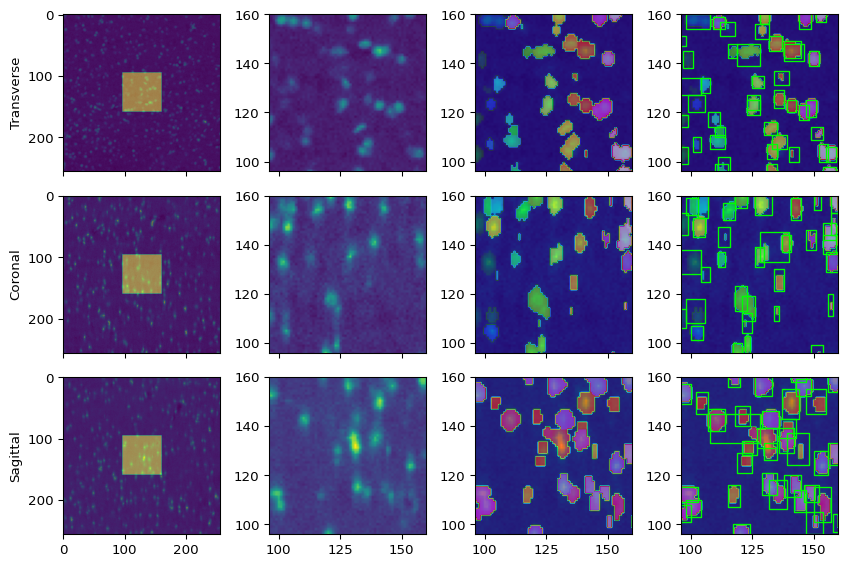

In [7]:
img0 = img[img.shape[0]//2,:,:]
img1 = img[:,img.shape[1]//2,:]
img2 = img[:,:,img.shape[2]//2]

mask0 = mask[mask.shape[0]//2,:,:]
mask1 = mask[:,mask.shape[1]//2,:]
mask2 = mask[:,:,mask.shape[2]//2]

boundary_mask_path = '/ifshome/abenneck/docs_public/misc_outputs/gt_data/mask64_i0002_j0005_k0003.nii.gz'
boundary_mask = nib.load(boundary_mask_path)
boundary_mask = boundary_mask.get_fdata()

boundary_mask0 = boundary_mask[boundary_mask.shape[0]//2,:,:]
boundary_mask1 = boundary_mask[:,boundary_mask.shape[1]//2,:]
boundary_mask2 = boundary_mask[:,:,boundary_mask.shape[2]//2]

lim = [96,160]

fig, axs = plt.subplots(3, 4, layout='tight', sharex='col')
axs[0,0].imshow(img0)
axs[0,0].imshow(boundary_mask0, alpha = 0.5)
axs[0,1].imshow(img0)
axs[0,2].imshow(img0)
axs[0,2].imshow(mask0, cmap = 'gist_ncar', alpha = 0.5)
axs[0,3].imshow(img0)
axs[0,3].imshow(mask0, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 0, img.shape[0]//2), pos = [4, 2, 5, 3], fc='none', ec='lime')
axs[0,3].add_collection(bb_plot)
axs[0,0].set_ylabel('Transverse')

axs[1,0].imshow(img1)
axs[1,0].imshow(boundary_mask1, alpha = 0.5)
axs[1,1].imshow(img1)
axs[1,2].imshow(img1)
axs[1,2].imshow(mask1, cmap = 'gist_ncar', alpha = 0.5)
axs[1,3].imshow(img1)
axs[1,3].imshow(mask1, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 1, img.shape[1]//2), pos = [4, 0, 5, 1], fc='none', ec='lime')
axs[1,3].add_collection(bb_plot)
axs[1,0].set_ylabel('Coronal')

axs[2,0].imshow(img2)
axs[2,0].imshow(boundary_mask2, alpha = 0.5)
axs[2,1].imshow(img2)
axs[2,2].imshow(img2)
axs[2,2].imshow(mask2, cmap = 'gist_ncar', alpha = 0.5)
axs[2,3].imshow(img2)
axs[2,3].imshow(mask2, cmap = 'gist_ncar', alpha = 0.5)
bb_plot = bb_to_rec(bb_slice_filter(gt_bb, 2, img.shape[2]//2), pos = [2, 0, 3, 1], fc='none', ec='lime')
axs[2,3].add_collection(bb_plot)
axs[2,0].set_ylabel('Sagittal')

for ax in axs:
    for ax_i in ax[1:]:
        ax_i.set_xlim(lim)
        ax_i.set_ylim(lim)

fig.set_size_inches(9,6)

### Compare original input img to preprocessed input img

Text(0.5, 1.0, 'Preprocessing')

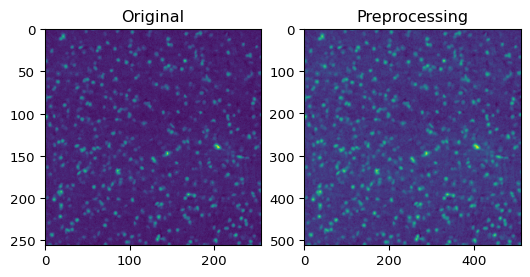

In [57]:
fig, axs = plt.subplots(1,2)

axs[0].imshow(img[0])
axs[0].set_title('Original')

axs[1].imshow(img_up[0])
axs[1].set_title('Preprocessing')

# (1) Apply each model to the target volume

In [15]:
# Segment annotated region from original img, to dec memory cost
img_ann = img[96:160, 96:160, 96:160]
print(f'Annotated area size: {img_ann.shape}')

# In original dataset, avg cell diameter is 5-8 voxels, so upsamping inc this to 10-16 voxels
img_up = preprocess_3D(img_ann)
print(f'(Upsampled) Annotated area size: {img_up.shape}')

Annotated area size: (64, 64, 64)
(Upsampled) Annotated area size: (128, 128, 128)


In [16]:
# Apply YOLO (img is upsampled and gamma corrected)
start = time.time()
outdir_slices = '/ifshome/abenneck/docs_public/misc_outputs/gt_data/slices'
outdir_cube = '/ifshome/abenneck/docs_public/misc_outputs/gt_data/cube'
apply_2D_yolo_to_slices(img_path, model_path, outdir_slices, verbose = False)
yolo_out = stitch_slices_into_cube(os.path.join(outdir_slices,'ax0'), os.path.join(outdir_slices,'ax1'), os.path.join(outdir_slices,'ax2'), outdir_cube)
yolo_nms = NMS(yolo_out)
print(f'Finished applying YOLO model in {time.time() - start:.2f}s')

# Apply Stardist
start = time.time()
stardist_labels, stardist_raw_outputs = star_model.predict_instances(img_up)
print(f'Finished applying StarDist model in {time.time() - start:.2f}s')

# Apply Cellpose
img_3ch = img_up[None] # Add a channel dimension since, CellPose requires the input image to have "at least 3 channels"
start = time.time()
masks_stitched, flows_stitched, _ = cell_model.eval(img_3ch, z_axis=1, channel_axis=0,
                                                  batch_size=32,
                                                  do_3D=False, stitch_threshold=0.5)
print(f'Finished applying CellPose model in {time.time() - start:.2f}s')

yolo_3D_pipeline_help.py (90): To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


Total Cubes Shape: (1, 1, 1)
Starting cube (0,0,0) . . .
Edge? - True True True
Extent: [1.5,1021.5],[1.5,1021.5],[1.5,1021.5]
Extent_i:  [0,255],[0,255],[0,255]
Finished initializing global variables and data structures . . .
Finished combining detections along transverse view . . .
Finished combining detections along coronal view . . .
Finished combining detections along sagittal view . . .
(64, 64, 64, 8),(64, 64, 64, 8),(64, 64, 64, 8)
Finished cube (0,0,0) in 4.72s

................................................................99.46% of bboxes removed
Finished applying YOLO model in 51.95s
Finished applying StarDist model in 2.58s


100%|██████████| 127/127 [00:00<00:00, 712.97it/s]


Finished applying CellPose model in 181.41s


### (BROKEN) Visualize Data (Original img of s=256 + annotation of s=64)
- TODO?: In order to generate a plot in the units of the original img, the bb coords must be adjusted for the StarDist and CellPose outputs
- The NEXT plot is in units of the annotated + upsampled region, where the bb coords for GT and YOLO datasets are adjusted

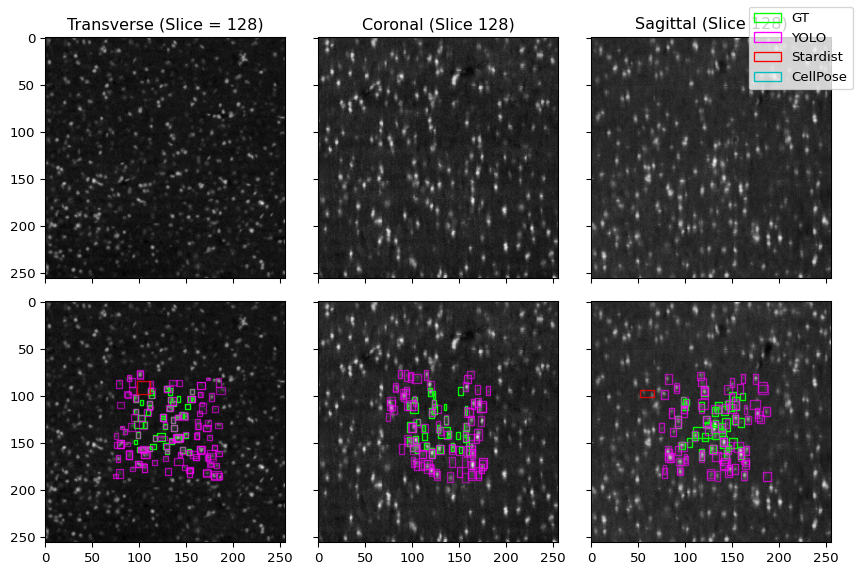

In [78]:
img_m0_idx = img.shape[0]//2
img_m1_idx = img.shape[1]//2
img_m2_idx = img.shape[2]//2

img0 = img[img_m0_idx,:,:]
img1 = img[:,img_m1_idx,:]
img2 = img[:,:,img_m2_idx]

lim = [96,160]

yolo_conf_thresh = 0.5
yolo_bb = yolo_output_to_bb_list(yolo_out)
star_bb = stardist_to_bb_list(stardist_raw_outputs, mode='3D')
cell_bb = cellpose_to_bb_list(masks_stitched)

# Each row will be a different angle, and each col will be (img, img+outputs)
fig, axs = plt.subplots(2,3,layout='tight', sharex=True, sharey=True)

# ==============================
# ===== Col 0 (Transverse) =====
# ==============================
# Original image
axs[0,0].imshow(img0, cmap='gray')
axs[0,0].set_title(f'Transverse (Slice = {img_m0_idx})')

# Original image
axs[1,0].imshow(img0, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 0, img_m0_idx), pos = [4, 2, 5, 3], fc='none', ec='lime')
axs[1,0].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb, 0, img_m0_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 2, 5, 3], fc='none', ec='magenta', alpha=scores)
axs[1,0].add_collection(bb_plot_yolo)

# Stardist bboxes
bb_star = bb_slice_filter(star_bb, 0, img_m0_idx)
if len(bb_star) > 0:
    scores = bb_star[:,-1]
    bb_plot_star = bb_to_rec(bb_star, pos = [4, 2, 5, 3], fc='none', ec='red', alpha=scores)
    axs[1,0].add_collection(bb_plot_star)

# CellPose bboxes
bb_cell = bb_slice_filter(cell_bb, 0, img_m0_idx)
if len(bb_cell) > 0:
    bb_plot_cell = bb_to_rec(bb_cell, pos = [4, 2, 5, 3], fc='none', ec='c')
    axs[1,0].add_collection(bb_plot_cell)

# ===========================
# ===== Col 1 (Coronal) =====
# ===========================
# Original image
axs[0,1].imshow(img1, cmap='gray')
axs[0,1].set_title(f'Coronal (Slice {img_m1_idx})')

# Original image
axs[1,1].imshow(img1, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 1, img_m1_idx), pos = [4, 0, 5, 1], fc='none', ec='lime')
axs[1,1].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb, 1, img_m1_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 0, 5, 1], fc='none', ec='magenta', alpha=scores)
axs[1,1].add_collection(bb_plot_yolo)

# Stardist bboxes
bb_star = bb_slice_filter(star_bb, 1, img_m1_idx)
if len(bb_star) > 0:
    scores = bb_star[:,-1]
    bb_plot_star = bb_to_rec(bb_star, pos = [4, 0, 5, 1], fc='none', ec='red', alpha=scores)
    axs[1,1].add_collection(bb_plot_star)

# CellPose bboxes
bb_cell = bb_slice_filter(cell_bb, 1, img_m1_idx)
if len(bb_cell) > 0:
    bb_plot_cell = bb_to_rec(bb_cell, pos = [4, 0, 5, 1], fc='none', ec='c')
    axs[1,1].add_collection(bb_plot_cell)


# ============================
# ===== Col 2 (Sagittal) =====
# ============================
# Original image
axs[0,2].imshow(img2, cmap='gray')
axs[0,2].set_title(f'Sagittal (Slice {img_m2_idx})')

# Original image
axs[1,2].imshow(img2, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 2, img_m2_idx), pos = [2, 0, 3, 1], fc='none', ec='lime')
axs[1,2].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb, 2, img_m2_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [2, 0, 3, 1], fc='none', ec='magenta', alpha=scores)
axs[1,2].add_collection(bb_plot_yolo)

# Stardist bboxes
bb_star = bb_slice_filter(star_bb, 2, img_m2_idx)
if len(bb_star) > 0:
    scores = bb_star[:,-1]
    bb_plot_star = bb_to_rec(bb_star, pos = [2, 0, 3, 1], fc='none', ec='red', alpha=scores)
    axs[1,2].add_collection(bb_plot_star)

# CellPose bboxes
bb_cell = bb_slice_filter(cell_bb, 2, img_m2_idx)
if len(bb_cell) > 0:
    bb_plot_cell = bb_to_rec(bb_cell, pos = [2, 0, 3, 1], fc='none', ec='c')
    axs[1,2].add_collection(bb_plot_cell)

# ========================
# ===== Whole Figure =====
# ========================

# Set same limits for every view
# for ax in axs:
#     for ax_i in ax:
#         ax_i.set_xlim(lim)
#         ax_i.set_ylim(lim)

# Generate a legend for the figure
legend_handles = [
    Patch(facecolor='none', edgecolor="lime", label="GT"),
    Patch(facecolor='none', edgecolor="magenta", label="YOLO"),
    Patch(facecolor='none', edgecolor="red", label="Stardist"),
    Patch(facecolor='none', edgecolor="c", label="CellPose"),
]
fig.legend(handles=legend_handles)

fig.set_size_inches(9,6)

### Visualize Data (Only the annotated area of s=64)

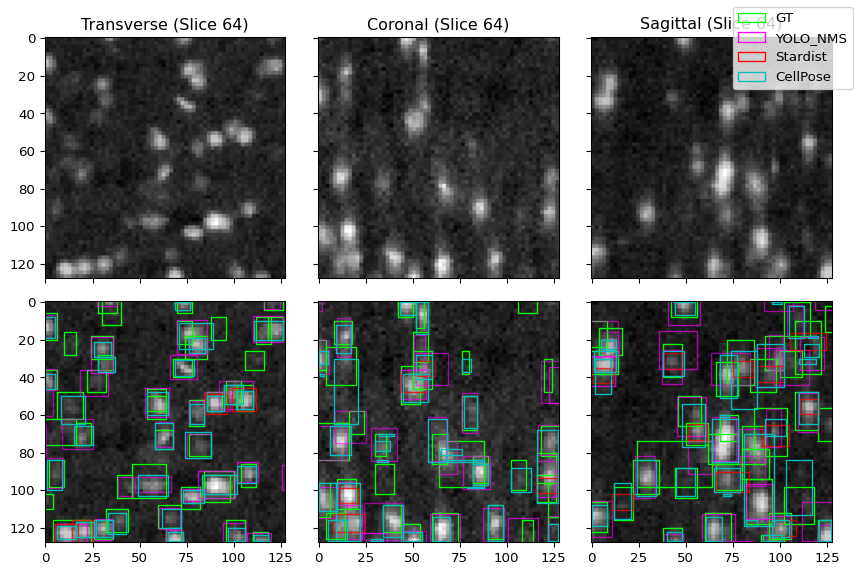

In [75]:
img_m0_idx = img_up.shape[0]//2
img_m1_idx = img_up.shape[1]//2
img_m2_idx = img_up.shape[2]//2

img0 = img_up[img_m0_idx,:,:]
img1 = img_up[:,img_m1_idx,:]
img2 = img_up[:,:,img_m2_idx]

lim = [96,160]

yolo_conf_thresh = 0.5
# yolo_bb = yolo_output_to_bb_list(yolo_out)
yolo_bb = yolo_output_to_bb_list(yolo_nms)
star_bb = stardist_to_bb_list(stardist_raw_outputs, mode='3D')
cell_bb = cellpose_to_bb_list(masks_stitched)

# Convert to relative units (YOLO and GT are in units of the original img, but Star and Cell are in units of the segmented, upsampled annotated region
gt_bb_adjusted = convert_bb_units(gt_bb)
yolo_bb_adjusted = convert_bb_units(yolo_bb)

# Each row will be a different angle, and each col will be (img, img+outputs)
fig, axs = plt.subplots(2,3,layout='tight', sharex=True, sharey=True)

# ==============================
# ===== Col 0 (Transverse) =====
# ==============================
# Original image
axs[0,0].imshow(img0, cmap='gray')
axs[0,0].set_title(f'Transverse (Slice {img_m0_idx})')

# Original image
axs[1,0].imshow(img0, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb_adjusted, 0, img_m0_idx), pos = [4, 2, 5, 3], fc='none', ec='lime')
axs[1,0].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb_adjusted, 0, img_m0_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 2, 5, 3], fc='none', ec='magenta', alpha=scores)
axs[1,0].add_collection(bb_plot_yolo)

# Stardist bboxes
bb_star = bb_slice_filter(star_bb, 0, img_m0_idx)
if len(bb_star) > 0:
    scores = bb_star[:,-1]
    bb_plot_star = bb_to_rec(bb_star, pos = [4, 2, 5, 3], fc='none', ec='red', alpha=scores)
    axs[1,0].add_collection(bb_plot_star)

# CellPose bboxes
bb_cell = bb_slice_filter(cell_bb, 0, img_m0_idx)
if len(bb_cell) > 0:
    bb_plot_cell = bb_to_rec(bb_cell, pos = [4, 2, 5, 3], fc='none', ec='c')
    axs[1,0].add_collection(bb_plot_cell)

# ===========================
# ===== Col 1 (Coronal) =====
# ===========================
# Original image
axs[0,1].imshow(img1, cmap='gray')
axs[0,1].set_title(f'Coronal (Slice {img_m1_idx})')

# Original image
axs[1,1].imshow(img1, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb_adjusted, 1, img_m1_idx), pos = [4, 0, 5, 1], fc='none', ec='lime')
axs[1,1].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb_adjusted, 1, img_m1_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 0, 5, 1], fc='none', ec='magenta', alpha=scores)
axs[1,1].add_collection(bb_plot_yolo)

# Stardist bboxes
bb_star = bb_slice_filter(star_bb, 1, img_m1_idx)
if len(bb_star) > 0:
    scores = bb_star[:,-1]
    bb_plot_star = bb_to_rec(bb_star, pos = [4, 0, 5, 1], fc='none', ec='red', alpha=scores)
    axs[1,1].add_collection(bb_plot_star)

# CellPose bboxes
bb_cell = bb_slice_filter(cell_bb, 1, img_m1_idx)
if len(bb_cell) > 0:
    bb_plot_cell = bb_to_rec(bb_cell, pos = [4, 0, 5, 1], fc='none', ec='c')
    axs[1,1].add_collection(bb_plot_cell)


# ============================
# ===== Col 2 (Sagittal) =====
# ============================
# Original image
axs[0,2].imshow(img2, cmap='gray')
axs[0,2].set_title(f'Sagittal (Slice {img_m2_idx})')

# Original image
axs[1,2].imshow(img2, cmap='gray')

# GT bboxes
bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb_adjusted, 2, img_m2_idx), pos = [2, 0, 3, 1], fc='none', ec='lime')
axs[1,2].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb_adjusted, 2, img_m2_idx)
scores = bb_yolo[:,-4]
scores[scores < yolo_conf_thresh] = 0.0
bb_plot_yolo = bb_to_rec(bb_yolo, pos = [2, 0, 3, 1], fc='none', ec='magenta', alpha=scores)
axs[1,2].add_collection(bb_plot_yolo)

# Stardist bboxes
bb_star = bb_slice_filter(star_bb, 2, img_m2_idx)
if len(bb_star) > 0:
    scores = bb_star[:,-1]
    bb_plot_star = bb_to_rec(bb_star, pos = [2, 0, 3, 1], fc='none', ec='red', alpha=scores)
    axs[1,2].add_collection(bb_plot_star)

# CellPose bboxes
bb_cell = bb_slice_filter(cell_bb, 2, img_m2_idx)
if len(bb_cell) > 0:
    bb_plot_cell = bb_to_rec(bb_cell, pos = [2, 0, 3, 1], fc='none', ec='c')
    axs[1,2].add_collection(bb_plot_cell)

# ========================
# ===== Whole Figure =====
# ========================

# Set same limits for every view
# for ax in axs:
#     for ax_i in ax:
#         ax_i.set_xlim(lim)
#         ax_i.set_ylim(lim)

# Generate a legend for the figure
legend_handles = [
    Patch(facecolor='none', edgecolor="lime", label="GT"),
    Patch(facecolor='none', edgecolor="magenta", label="YOLO_NMS"),
    Patch(facecolor='none', edgecolor="red", label="Stardist"),
    Patch(facecolor='none', edgecolor="c", label="CellPose"),
]
fig.legend(handles=legend_handles)

fig.set_size_inches(9,6)

### Plot all bb pruned during NMS

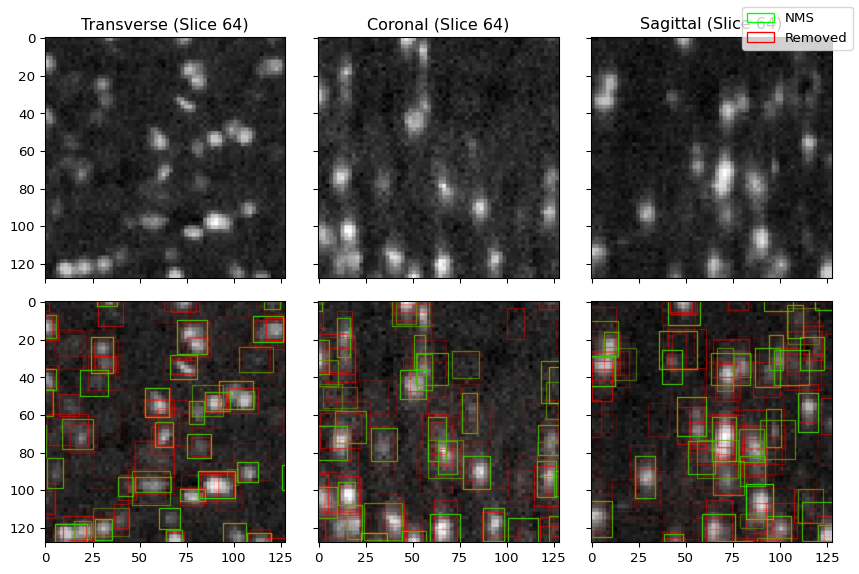

In [76]:
img_m0_idx = img_up.shape[0]//2
img_m1_idx = img_up.shape[1]//2
img_m2_idx = img_up.shape[2]//2

img0 = img_up[img_m0_idx,:,:]
img1 = img_up[:,img_m1_idx,:]
img2 = img_up[:,:,img_m2_idx]

lim = [96,160]

# Convert YOLO outputs into lists of bboxes
yolo_bb = yolo_output_to_bb_list(yolo_out)
yolo_bb_nms = yolo_output_to_bb_list(yolo_nms)

# Convert to relative units (YOLO and GT are in units of the original img, but Star and Cell are in units of the segmented, upsampled annotated region
gt_bb_adjusted = convert_bb_units(gt_bb)
yolo_bb = convert_bb_units(yolo_bb)
yolo_bb_nms = convert_bb_units(yolo_bb_nms)

# Each row will be a different angle, and each col will be (img, img+outputs)
fig, axs = plt.subplots(2,3,layout='tight', sharex=True, sharey=True)

# ==============================
# ===== Col 0 (Transverse) =====
# ==============================
# Original image
axs[0,0].imshow(img0, cmap='gray')
axs[0,0].set_title(f'Transverse (Slice {img_m0_idx})')

# Original image
axs[1,0].imshow(img0, cmap='gray')

# GT bboxes
# bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 0, img_m0_idx), pos = [4, 2, 5, 3], fc='none', ec='lime')
# axs[1,0].add_collection(bb_plot_gt)

# YOLO bboxes (Orig)
bb_yolo = bb_slice_filter(yolo_bb, 0, img_m0_idx)
if len(bb_yolo) > 0:
    scores = bb_yolo[:,-4]
    bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 2, 5, 3], fc='none', ec='red', alpha=scores)
    axs[1,0].add_collection(bb_plot_yolo)

bb_yolo_nms = bb_slice_filter(yolo_bb_nms, 0, img_m0_idx)
if len(bb_yolo_nms) > 0:
    scores = bb_yolo_nms[:,-4]
    bb_plot_yolo_nms = bb_to_rec(bb_yolo_nms, pos = [4, 2, 5, 3], fc='none', ec='lime', alpha=scores)
    axs[1,0].add_collection(bb_plot_yolo_nms)

# ===========================
# ===== Col 1 (Coronal) =====
# ===========================
# Original image
axs[0,1].imshow(img1, cmap='gray')
axs[0,1].set_title(f'Coronal (Slice {img_m1_idx})')

# Original image
axs[1,1].imshow(img1, cmap='gray')

# GT bboxes
# bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 1, img_m1_idx), pos = [4, 0, 5, 1], fc='none', ec='lime')
# axs[1,1].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb, 1, img_m1_idx)
if len(bb_yolo) > 0:
    scores = bb_yolo[:,-4]
    bb_plot_yolo = bb_to_rec(bb_yolo, pos = [4, 0, 5, 1], fc='none', ec='red', alpha=scores)
    axs[1,1].add_collection(bb_plot_yolo)

bb_yolo_nms = bb_slice_filter(yolo_bb_nms, 1, img_m1_idx)
if len(bb_yolo_nms) > 0:
    scores = bb_yolo_nms[:,-4]
    bb_plot_yolo_nms = bb_to_rec(bb_yolo_nms, pos = [4, 0, 5, 1], fc='none', ec='lime', alpha=scores)
    axs[1,1].add_collection(bb_plot_yolo_nms)


# ============================
# ===== Col 2 (Sagittal) =====
# ============================
# Original image
axs[0,2].imshow(img2, cmap='gray')
axs[0,2].set_title(f'Sagittal (Slice {img_m2_idx})')

# Original image
axs[1,2].imshow(img2, cmap='gray')

# GT bboxes
# bb_plot_gt = bb_to_rec(bb_slice_filter(gt_bb, 2, img_m2_idx), pos = [2, 0, 3, 1], fc='none', ec='lime')
# axs[1,2].add_collection(bb_plot_gt)

# YOLO bboxes
bb_yolo = bb_slice_filter(yolo_bb, 2, img_m2_idx)
if len(bb_yolo) > 0:
    scores = bb_yolo[:,-4]
    bb_plot_yolo = bb_to_rec(bb_yolo, pos = [2, 0, 3, 1], fc='none', ec='red', alpha=scores)
    axs[1,2].add_collection(bb_plot_yolo)

bb_yolo_nms = bb_slice_filter(yolo_bb_nms, 2, img_m2_idx)
if len(bb_yolo_nms) > 0:
    scores = bb_yolo_nms[:,-4]
    bb_plot_yolo_nms = bb_to_rec(bb_yolo_nms, pos = [2, 0, 3, 1], fc='none', ec='lime', alpha=scores)
    axs[1,2].add_collection(bb_plot_yolo_nms)

# ========================
# ===== Whole Figure =====
# ========================

# Set same limits for every view
# for ax in axs:
#     for ax_i in ax:
#         ax_i.set_xlim(lim)
#         ax_i.set_ylim(lim)

# Generate a legend for the figure
legend_handles = [
    Patch(facecolor='none', edgecolor="lime", label="NMS"),
    Patch(facecolor='none', edgecolor="red", label="Removed"),
]
fig.legend(handles=legend_handles)

fig.set_size_inches(9,6)

# (2) Compute AP, generate plots, and compare performance

### Compute AP (IOU = 0.5) for each model

In [17]:
# NOTE: Each element of the 'performance' object contains a list of values defined as follows:
# [idx, best_gt_iou_idx, pred_conf, best_gt_iou, TP, FP, total_TP, total_FP, precision, recall]

iou_thresh = 0.5

# Convert to relative units (YOLO and GT are in units of the original img, but Star and Cell are in units of the segmented, upsampled annotated region
gt_bb_adjusted = convert_bb_units(gt_bb)

# YOLO
# yolo_bb = yolo_output_to_bb_list(yolo_out)
# yolo_bb = yolo_output_to_bb_list(yolo_nms_filtered)
# yolo_bb_adjusted = convert_bb_units(yolo_bb)
# AP_yolo, perf_yolo = get_AP(gt_bb_adjusted, yolo_bb_adjusted, iou_thresh = iou_thresh, verbose = True)

yolo_nms_filtered = remove_low_conf_bb(yolo_nms)
yolo_bb_adjusted = convert_bb_units(yolo_nms_filtered)
AP_yolo, perf_yolo = get_AP(gt_bb_adjusted, yolo_bb_adjusted, iou_thresh = iou_thresh, verbose = True)

# Stardist
star_bb = stardist_to_bb_list(stardist_raw_outputs, mode = '3D')
AP_star, perf_star = get_AP(gt_bb_adjusted, star_bb, conf_idx = -1, iou_thresh = iou_thresh, verbose = True)

# Cellpose
cell_bb = cellpose_to_bb_list(masks_stitched)
AP_cell, perf_cell = get_AP(gt_bb_adjusted, cell_bb, conf_idx = -1, iou_thresh = iou_thresh, verbose = True)

print(f'AP_yolo: {AP_yolo:.2f} vs AP_star: {AP_star:.2f} vs AP_cell: {AP_cell:.2f} ')

AP_yolo: 0.04 vs AP_star: 0.00 vs AP_cell: 0.02 


In [18]:
print(f'GT: {len(gt_bb_adjusted)} total cells')
print()
print('Dataset: AP | # detections | total TP | total FP ')
print(f'YOLO: {AP_yolo:.4f} | {len(yolo_bb_adjusted)} | {perf_yolo[-1,-4].astype(int)} | {perf_yolo[-1,-3].astype(int)}')
print(f'StarDist: {AP_star:.4f} | {len(star_bb)} | {perf_star[-1,-4].astype(int)} | {perf_star[-1,-3].astype(int)}')
print(f'CellPose: {AP_cell:.4f} | {len(cell_bb)} | {perf_cell[-1,-4].astype(int)} | {perf_cell[-1,-3].astype(int)}')

GT: 276 total cells

Dataset: AP | # detections | total TP | total FP 
YOLO: 0.0380 | 1413 | 109 | 1304
StarDist: 0.0015 | 76 | 5 | 71
CellPose: 0.0182 | 379 | 46 | 333


### Plot results

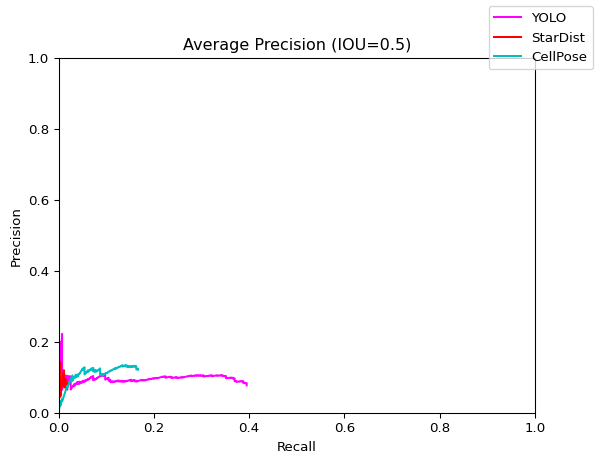

In [19]:
fig, ax = plt.subplots()
ax.plot(perf_yolo[:,-1], perf_yolo[:,-2], color='magenta', label='YOLO')
ax.plot(perf_star[:,-1], perf_star[:,-2], color='red', label='StarDist')
ax.plot(perf_cell[:,-1], perf_cell[:,-2], color='c', label='CellPose')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Average Precision (IOU={iou_thresh})')
ax.set_xlim([0,1])
ax.set_ylim([0,1])

_ = fig.legend()

# for bb in performance:
#     # If the bbox was a TP, plot it
#     if bb[3] == 1:
#         # print('Added point')
#         ax.scatter(bb[-1], bb[-2], color = 'green', linewidth = 0.5)

In [117]:
# [idx, best_gt_iou_idx, pred_conf, best_gt_iou, TP, FP, total_TP, total_FP, precision, recall]

# for elem in perf_star:
#     print(elem)

# for elem in star_bb:
#     print(elem)

cell_bb[20]

array([  0,   9,  92, 102,  15,  29,  21])

In [46]:
for idx, elem in enumerate(perf_yolo):
    if idx % 500 == 0:
        print(elem)
    if idx > 10000:
        break

[  0.         266.           0.84788263   0.35855731   0.
   1.           0.           1.           0.           0.        ]
[5.00000000e+02 0.00000000e+00 6.37864649e-01 0.00000000e+00
 0.00000000e+00 1.00000000e+00 4.30000000e+01 4.58000000e+02
 8.58283433e-02 1.55797101e-01]
[1.00000000e+03 0.00000000e+00 5.78290284e-01 0.00000000e+00
 0.00000000e+00 1.00000000e+00 9.30000000e+01 9.08000000e+02
 9.29070929e-02 3.36956522e-01]
[1.50000000e+03 0.00000000e+00 5.22511780e-01 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.21000000e+02 1.38000000e+03
 8.06129247e-02 4.38405797e-01]
[2.00000000e+03 1.78000000e+02 4.53685164e-01 4.12333382e-02
 0.00000000e+00 1.00000000e+00 1.34000000e+02 1.86700000e+03
 6.69665167e-02 4.85507246e-01]
[2.50000000e+03 0.00000000e+00 3.82419229e-01 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.46000000e+02 2.35500000e+03
 5.83766493e-02 5.28985507e-01]
[3.00000000e+03 0.00000000e+00 3.06370527e-01 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.51000000e+0

### Compute mAP (0.5:0.05:1.0) for each model

In [ ]:
all_mAP = []
for all_bb in [yolo_bb, star_bb, cell_bb]:
    rolling_AP = 0
    for iou in np.arange(0.5,1,0.05):
        AP, performance = get_AP(gt_bb, all_bb, iou_thresh = iou, verbose = False)
        rolling_AP += AP
    mAP = rolling_AP / 10
    all_mAP.append(mAP)

### Plot Results?